In [1]:
import sys, os
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import xarray as xr

sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

from cariaco_ssm_setup import (
    model, model_setup, model_setup_stability, generate_size_classes,
    compute_K_s, compute_mu_max_maranon, compute_I_max,
    compute_fish_kernel_vdl_joint,
)
from resize_cariaco_setup import make_resized_setup, build_cariaco_regenerators
from spectrum_plot import plot_normalised_biomass_spectrum
from xso.parscans import StabilityAnalysisHook

ZOO per-class flux decomposition (realized SS)
     ESD       Z_ss     assim  %fromZ ||    Pr<opt   Pr=opt   Pr>opt     quad      lin    fish |      Σloss       net
     2.0   2.15e-02  4.65e-03       0 ||  9.52e-05 3.05e-03 1.86e-04 2.50e-04 1.07e-030.00e+00 |   4.65e-03  -8.9e-06
     2.4   6.10e-03  1.19e-03       0 ||  6.69e-04 1.32e-11 1.28e-04 7.09e-05 3.04e-040.00e+00 |   1.17e-03  +1.3e-05
     3.4   1.37e-02  1.63e-03       0 ||  4.30e-04 0.00e+00 3.65e-04 1.60e-04 6.86e-040.00e+00 |   1.64e-03  -1.5e-05
     4.1   8.03e-03  8.95e-04       0 ||  8.24e-05 2.67e-04 3.56e-05 9.34e-05 4.01e-040.00e+00 |   8.79e-04  +1.6e-05
     4.8   2.69e-06  2.79e-07       0 ||  7.53e-08 1.89e-10 3.32e-08 3.13e-08 1.35e-070.00e+00 |   2.75e-07  +4.4e-09
     5.8   1.28e-02  1.22e-03       0 ||  1.54e-04 9.78e-05 1.86e-04 1.49e-04 6.38e-040.00e+00 |   1.22e-03  -7.9e-06
     6.9   3.72e-03  3.41e-04       0 ||  3.38e-05 6.76e-05 1.01e-05 4.34e-05 1.86e-040.00e+00 |   3.41e-04  +1.5e-07
     8.2 

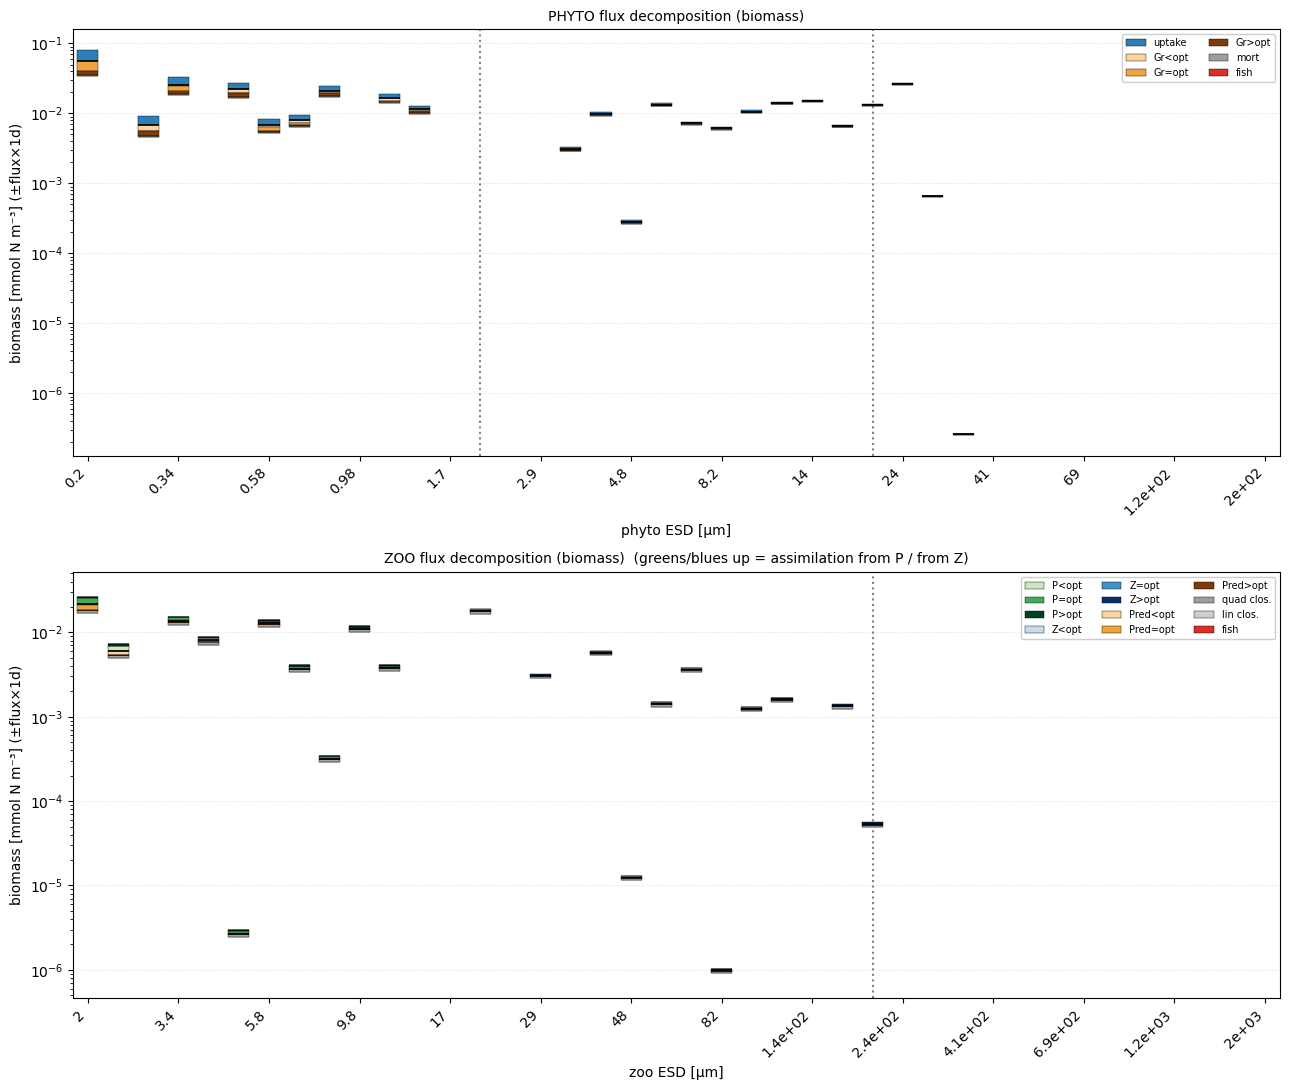

In [17]:
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_npzd_setups as cns, cariaco_obs as co, parscan_utils as pu, flux_plots_npzd as fpn
for m in (cns, co, pu, fpn): importlib.reload(m)

pe, ze, n = cns.phyto_esd, cns.zoo_esd, cns.N_CLASSES
FN_SHOW = 1.0
*_, forc = co.load_cariaco_targets(regime='upwelling', months='hplc', agg='median', include_temperature=True)
fixed = {k: v for k, v in forc.items() if k != 'Inflow__FN'}
# model_setup_npzd_tani is FULL output, so the grazing matrix is stored (needed by flux_plots_npzd)
out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani, scan_params={},
        fixed_overrides={**fixed, 'Inflow__FN': FN_SHOW,
                         'PhytoMortality__rate': np.full(n, 0.02), 'Grazing__KsZ': np.full(n, 0.23)})

fpn.summarize_zoo_fluxes(out, pe, ze)          # per-zoo-class table: %fromZ, loss split
fig, ax = plt.subplots(2, 1, figsize=(13, 11))
fpn.plot_phyto_flux_decomposition(out, pe, ze, mode='biomass', ax=ax[0])
fpn.plot_zoo_flux_decomposition(out, pe, ze, mode='biomass', ax=ax[1])
plt.tight_layout(); plt.show()

B0 (SS-mean per class) = 0.0184   -> ΣZ_uniform = 0.736, quad-closure ≈ 0.074 d⁻¹


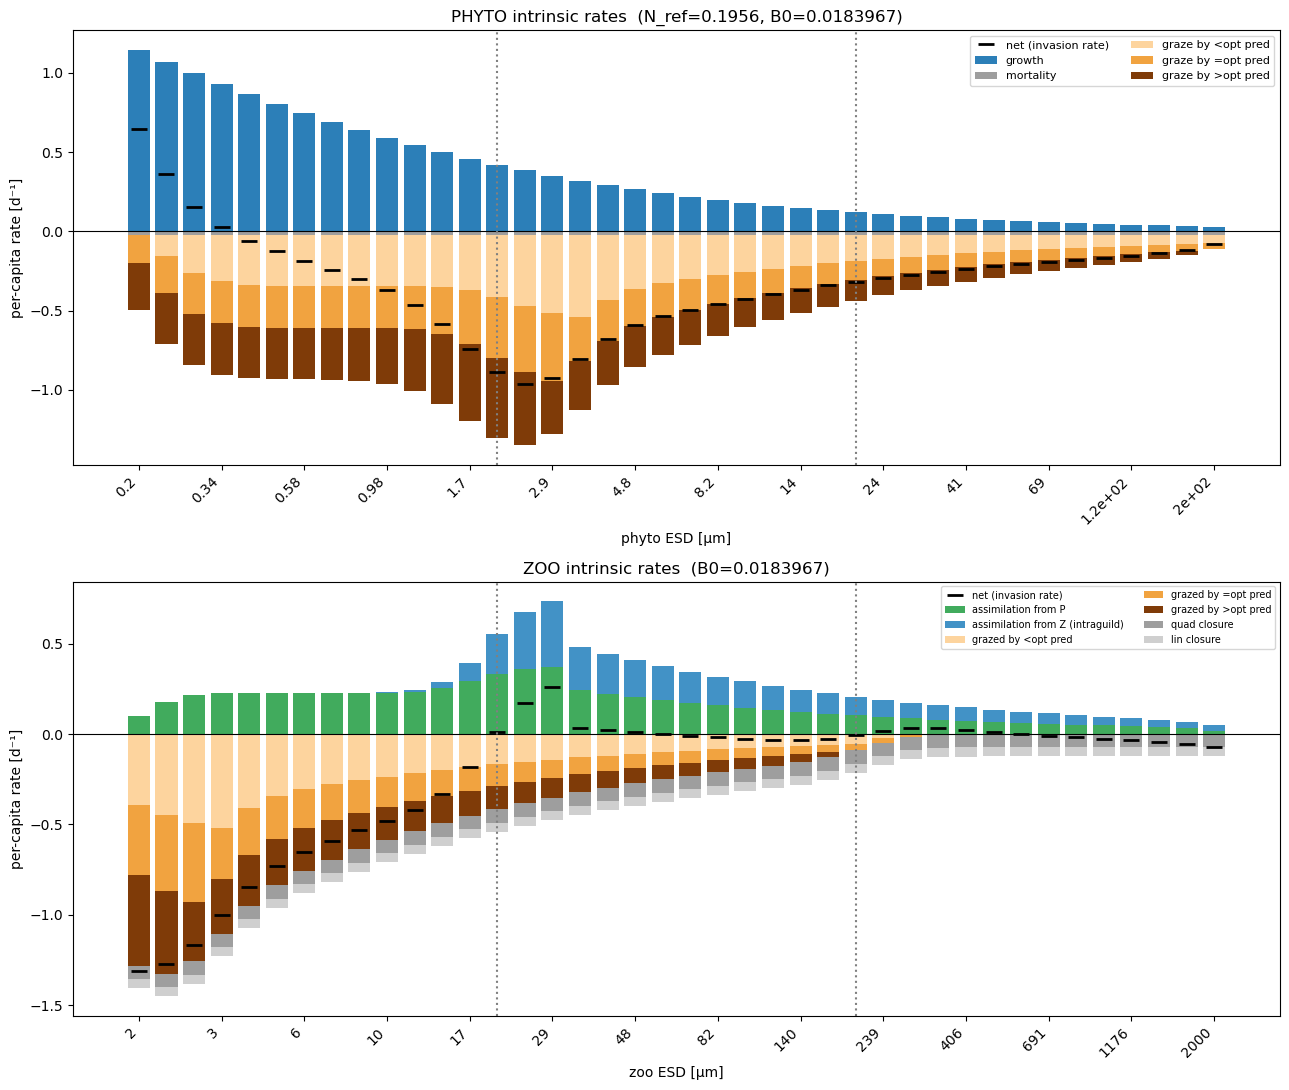

In [12]:
# after the run that gives out / Nss, set a realistic reference and replot
P = np.clip(np.asarray(out['Phytoplankton__biomass'].isel(time=slice(-1000,None)).mean('time').values), 0, None)
Z = np.clip(np.asarray(out['Zooplankton__biomass'].isel(time=slice(-1000,None)).mean('time').values), 0, None)
B0 = float(np.mean(np.concatenate([P[P > 1e-6], Z[Z > 1e-6]])))   # ~typical class biomass (~0.01), not 1.0
print(f"B0 (SS-mean per class) = {B0:.4f}   -> ΣZ_uniform = {B0*cns.N_CLASSES:.3f}, quad-closure ≈ {cns.M_Z*B0*cns.N_CLASSES:.3f} d⁻¹")

fig, ax = plt.subplots(2, 1, figsize=(13, 11))
fpn.plot_intrinsic_phyto(pe, ze, mu, ks, mP, Imax, KsZ, phi, N_ref=Nss, B0=B0, fT_grow=fTg, fT_graze=fTz, ax=ax[0])
fpn.plot_intrinsic_zoo(pe, ze, Imax, KsZ, phi, gge, mZ, mZl, B0=B0, fT_graze=fTz, ax=ax[1])
plt.tight_layout(); plt.show()

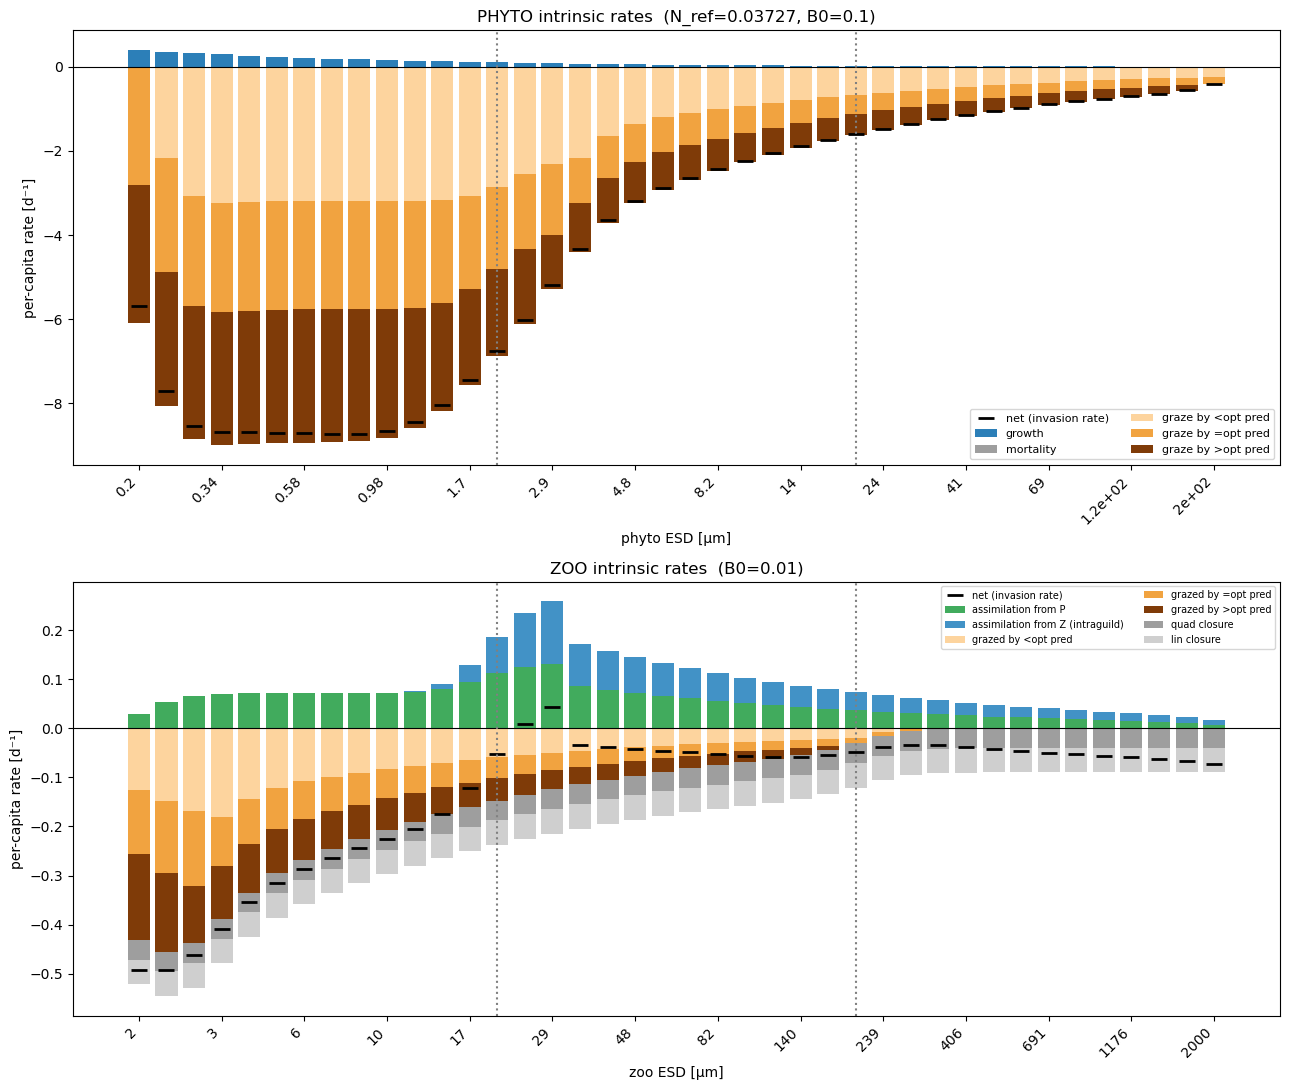

intrinsic at SS N_ref=0.0373, B0=1.0  (net>0 = class would grow from a uniform field)


In [16]:
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_npzd_setups as cns, cariaco_obs as co, parscan_utils as pu, flux_plots_npzd as fpn
for m in (cns, co, pu, fpn): importlib.reload(m)

pe, ze, n = cns.phyto_esd, cns.zoo_esd, cns.N_CLASSES
FN_SHOW = 1.0
mu, ks, mP = cns.mu_max_tani, cns.ks_tani, 0.02          # Taniguchi growth, Ward mortality
Imax, KsZ, phi = cns.Imax_arr, cns.K_SZ, cns.phiPZ_omni
gge, mZ, mZl = cns.GGE_VAL, cns.M_Z, cns.M_ZLIN
*_, forc = co.load_cariaco_targets(regime='upwelling', months='hplc', agg='median', include_temperature=True)
fixed = {k: v for k, v in forc.items() if k != 'Inflow__FN'}
fTg = cns.Q10_GROW ** ((forc['Temperature__value']-cns.T_REF)/10); fTz = cns.Q10_GRAZE ** ((forc['Temperature__value']-cns.T_REF)/10)

out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani_slim, scan_params={},
        fixed_overrides={**fixed, 'Inflow__FN': FN_SHOW, 'PhytoMortality__rate': np.full(n, mP), 'Grazing__KsZ': np.full(n, KsZ)})
Nss = float(np.asarray(out['Nutrient__value'].isel(time=slice(-1000, None)).mean('time').values))

fig, ax = plt.subplots(2, 1, figsize=(13, 11))
fpn.plot_intrinsic_phyto(pe, ze, mu, ks, mP, Imax, KsZ, phi, N_ref=Nss, B0=.1, fT_grow=fTg, fT_graze=fTz, ax=ax[0])
fpn.plot_intrinsic_zoo(pe, ze, Imax, KsZ, phi, gge, mZ, mZl, B0=.01, fT_graze=fTz, ax=ax[1])
plt.tight_layout(); plt.show()
print(f"intrinsic at SS N_ref={Nss:.4f}, B0=1.0  (net>0 = class would grow from a uniform field)")

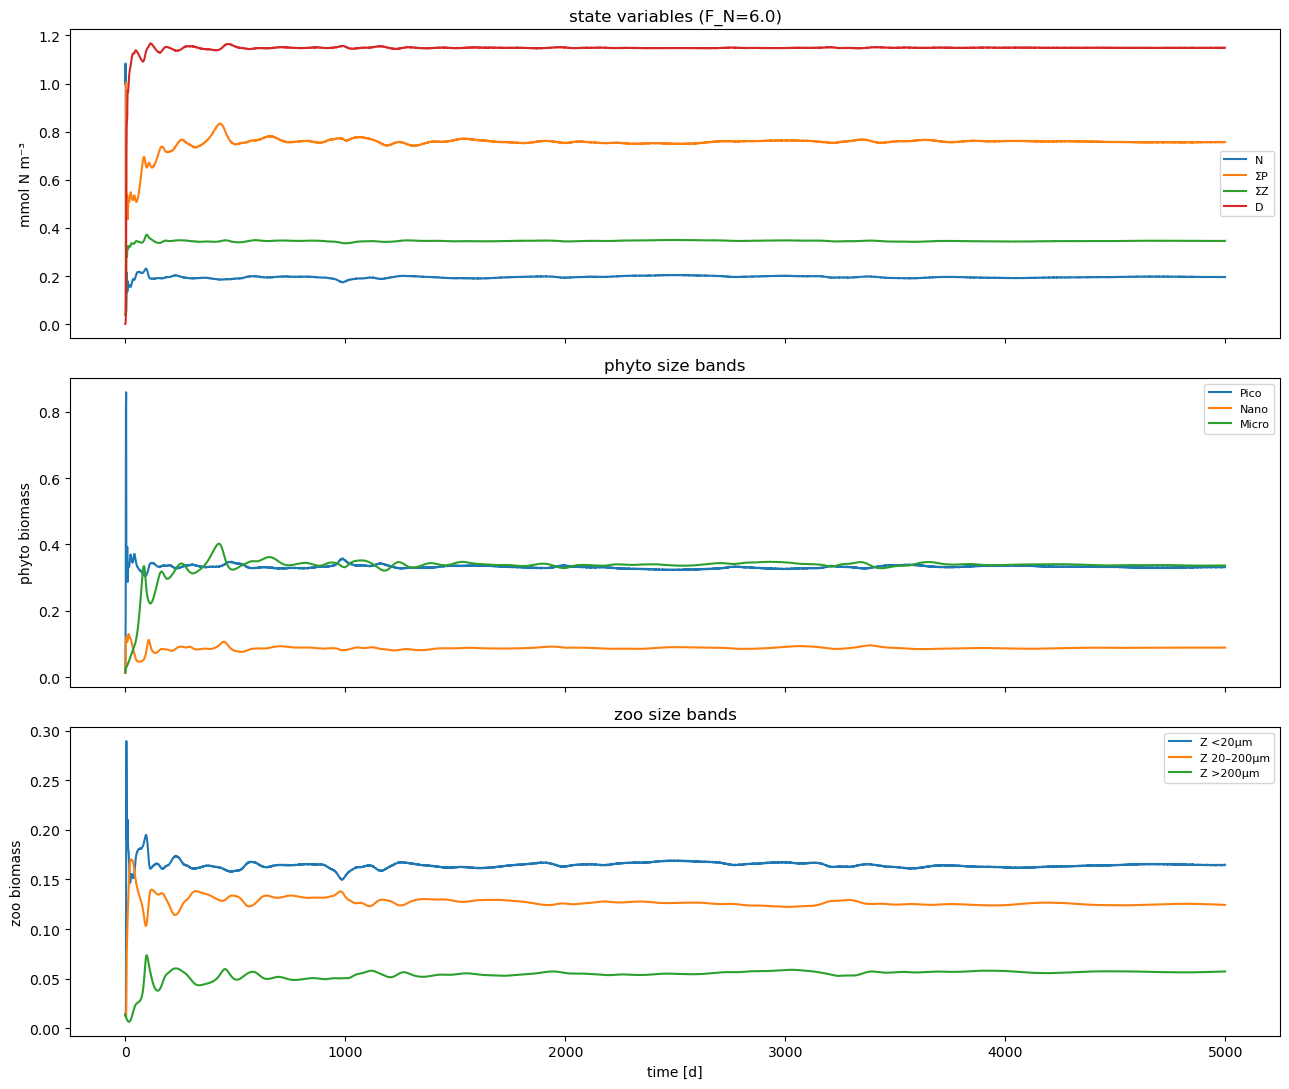

In [7]:
import importlib, numpy as np, matplotlib.pyplot as plt
import cariaco_npzd_setups as cns, cariaco_obs as co, parscan_utils as pu
for m in (cns, co, pu): importlib.reload(m)

pe, ze, n = cns.phyto_esd, cns.zoo_esd, cns.N_CLASSES
FN_SHOW = 6.0
*_, forc = co.load_cariaco_targets(regime='upwelling', months='hplc', agg='median', include_temperature=True)
fixed = {k: v for k, v in forc.items() if k != 'Inflow__FN'}
out = pu.run_single_point(cns.model_npzd, cns.model_setup_npzd_tani_slim, scan_params={},
        fixed_overrides={**fixed, 'Inflow__FN': FN_SHOW, 'PhytoMortality__rate': np.full(n, 0.02), 'Grazing__KsZ': np.full(n, 0.23)})

t = out['time'].values
N = out['Nutrient__value'].values; D = out['Detritus__value'].values
P = out['Phytoplankton__biomass'].transpose('time', 'phyto').values     # (time, phyto)
Z = out['Zooplankton__biomass'].transpose('time', 'zoo').values
pico, nano, micro = pe < 2, (pe >= 2) & (pe < 20), pe >= 20

fig, ax = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
ax[0].plot(t, N, label='N'); ax[0].plot(t, P.sum(1), label='ΣP'); ax[0].plot(t, Z.sum(1), label='ΣZ'); ax[0].plot(t, D, label='D')
ax[0].set_ylabel('mmol N m⁻³'); ax[0].set_title(f'state variables (F_N={FN_SHOW})'); ax[0].legend(fontsize=8)
ax[1].plot(t, P[:, pico].sum(1), label='Pico'); ax[1].plot(t, P[:, nano].sum(1), label='Nano'); ax[1].plot(t, P[:, micro].sum(1), label='Micro')
ax[1].set_ylabel('phyto biomass'); ax[1].set_title('phyto size bands'); ax[1].legend(fontsize=8)
ax[2].plot(t, Z[:, ze < 20].sum(1), label='Z <20µm'); ax[2].plot(t, Z[:, (ze>=20)&(ze<200)].sum(1), label='Z 20–200µm'); ax[2].plot(t, Z[:, ze>=200].sum(1), label='Z >200µm')
ax[2].set_xlabel('time [d]'); ax[2].set_ylabel('zoo biomass'); ax[2].set_title('zoo size bands'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

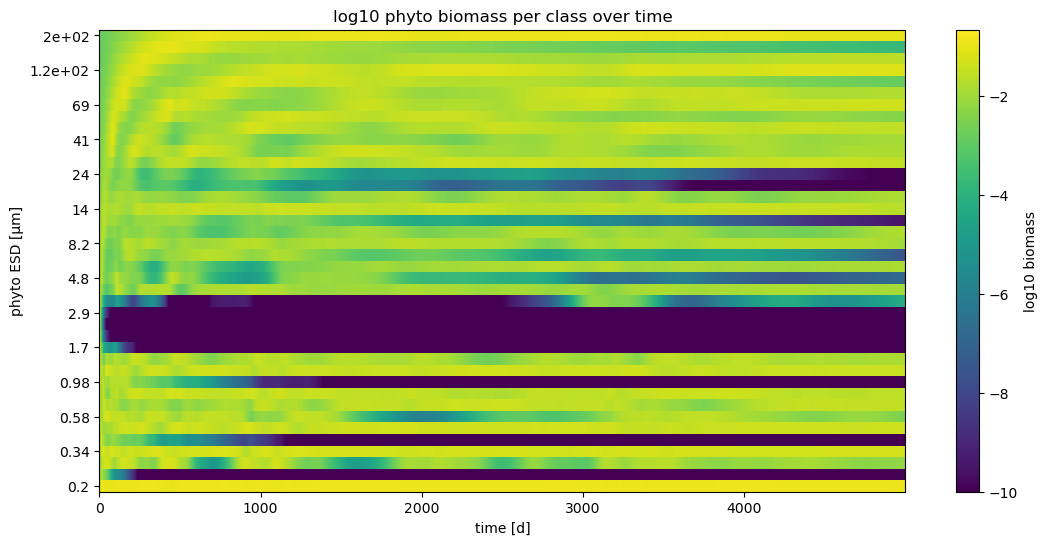

In [13]:
P2 = out['Phytoplankton__biomass'].transpose('phyto', 'time').values
fig, ax = plt.subplots(figsize=(13, 6))
im = ax.pcolormesh(out['time'].values, np.arange(n), np.log10(np.clip(P2, 1e-10, None)), shading='auto', cmap='viridis')
ax.set_yticks(np.arange(n)[::3]); ax.set_yticklabels([f'{e:.2g}' for e in pe[::3]])
ax.set_xlabel('time [d]'); ax.set_ylabel('phyto ESD [µm]'); ax.set_title('log10 phyto biomass per class over time')
plt.colorbar(im, label='log10 biomass'); plt.show()